In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import (ZScaleInterval, ImageNormalize, SqrtStretch)

import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator
from astropy import wcs
import warnings


In [2]:
# load the image with injected companions
sci = fits.getdata('injected_accreting_trace_sub.fits')    


Text(0.5, 1.0, '2D spectra with injected companions')

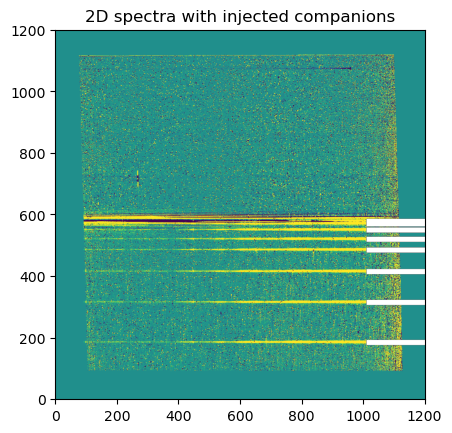

In [3]:
interval = ZScaleInterval()
vmin, vmax = interval.get_limits(sci)
plt.imshow(sci, vmin=vmin, vmax=vmax, origin='lower')
plt.title('2D spectra with injected companions')

In [4]:
window = 15
trace_center = 582
xcol_value = 400
yrange = np.arange(len(sci[:,xcol_value]))

In [25]:
def extract_spectrum(data, yrange, trace_center, half_window=10, bin_size=100,
                     plot=False, plot_every=50):
    """
    Optimally extract a 1D spectrum from a 2D spectral image using a
    median master profile as the spatial weighting function (Horne 1986).
    The master profile is computed per bin and interpolated between bins
    to account for slow PSF variations across the detector.

    Parameters
    ----------
    data         : 2D array (nrows, ncols)
    yrange       : 1D array of pixel positions along spatial axis
    trace_center : approximate center row of the trace
    half_window  : rows on each side of trace_center to include
    bin_size     : columns to median-combine per bin for master profile
    plot         : if True, plot data vs weighted extraction for selected columns
    plot_every   : plot every Nth column (default 50)

    Returns
    -------
    spectrum     : 1D array (ncols) — optimally extracted flux per column
    spectrum_err : 1D array (ncols) — uncertainty per column (from fit residuals)
    fit_params   : dict of 1D arrays with 'amplitude', 'amplitude_err', 'background'
    """
    nrows, ncols = data.shape
    pmin = trace_center - half_window
    pmax = trace_center + half_window
    rows_in_window = yrange[pmin:pmax]

    spectrum     = np.full(ncols, np.nan)
    spectrum_err = np.full(ncols, np.nan)
    fit_params   = {'amplitude':     np.full(ncols, np.nan),
                    'amplitude_err': np.full(ncols, np.nan),
                    'background':    np.full(ncols, np.nan)}

    # ── helper: build a normalized master profile from a column range ──────────
    def make_master_profile(col_start, col_end):
            cols    = data[pmin:pmax, col_start:col_end]
            bin_col = np.nanmedian(cols, axis=1)
            bg      = np.nanmedian(np.concatenate([bin_col[:2], bin_col[-2:]]))
            sub     = np.maximum(bin_col - bg, 0)
            total   = np.sum(sub)
            if total <= 0:
                return None
            profile = sub / total

            # ── sanity checks: reject pathological profiles ────────────────────
            # 1. no negative values
            if np.any(profile < 0):
                print(f"    rejected: negative values in profile")
                return None

            # 2. single-peaked — the peak should have no secondary maxima
            #    check by counting the number of times the profile crosses
            #    half its peak value (a single peak crosses exactly twice)
            half_max     = np.max(profile) / 2.0
            above_half   = profile >= half_max
            transitions  = np.diff(above_half.astype(int))
            n_rises      = np.sum(transitions == 1)
            if n_rises > 1:
                print(f"    rejected: multi-peaked profile ({n_rises} peaks above half-max)")
                return None

            # 3. peak must be interior — not sitting at the window edge
            #    (edge peak usually means the trace has drifted out of the window)
            peak_idx = np.argmax(profile)
            if peak_idx == 0 or peak_idx == len(profile) - 1:
                print(f"    rejected: peak at window edge (row {pmin + peak_idx})")
                return None

            # 4. profile must be reasonably concentrated —
            #    guard against a very flat/smeared profile caused by a bad region
            #    (peak should contain at least 10% of total weight)
            if np.max(profile) < 0.10:
                print(f"    rejected: peak too flat (max={np.max(profile):.3f})")
                return None

            return profile

    # ── stage 1: build one master profile per bin ─────────────────────────────
    print("Stage 1: building master profiles...")
    master_profiles = []
    bin_centers     = []

    for j in range(ncols // bin_size):
        col_start = bin_size * j
        col_end   = min(col_start + bin_size, ncols)
        profile   = make_master_profile(col_start, col_end)
        center    = (col_start + col_end) / 2.0

        if profile is not None:
            master_profiles.append({'col_center': center, 'profile': profile})
            print(f"  bin {j:2d} (cols {col_start:4d}–{col_end:4d}): "
                  f"peak row {pmin + np.argmax(profile)}")
        else:
            print(f"  bin {j:2d} (cols {col_start:4d}–{col_end:4d}): "
                  f"REJECTED — borrowing from nearest valid bin")        

        # if profile is not None:
        #     master_profiles.append({'col_center': center, 'profile': profile})
        #     print(f"  bin {j:2d} (cols {col_start:4d}–{col_end:4d}): "
        #           f"peak row {pmin + np.argmax(profile)}")
        # else:
        #     print(f"  bin {j:2d} (cols {col_start:4d}–{col_end:4d}): FAILED")

    if len(master_profiles) == 0:
        raise ValueError("No master profiles could be built — check trace_center and half_window")

    print(f"{len(master_profiles)}/{ncols // bin_size} bins built successfully.\n")

    # ── helper: interpolate master profile at any column position ─────────────
    def get_interpolated_profile(xcol):
        centers  = np.array([p['col_center'] for p in master_profiles])
        profiles = np.array([p['profile']    for p in master_profiles])

        if xcol <= centers[0]:
            return profiles[0]
        if xcol >= centers[-1]:
            return profiles[-1]

        idx_r = np.searchsorted(centers, xcol)
        idx_l = idx_r - 1
        t     = (xcol - centers[idx_l]) / (centers[idx_r] - centers[idx_l])

        interp = (1 - t) * profiles[idx_l] + t * profiles[idx_r]
        total  = np.sum(interp)
        return interp / total if total > 0 else profiles[idx_l]

    # ── stage 2: optimal extraction column by column ───────────────────────────
    print("Stage 2: extracting spectrum...")
    for xcol in range(ncols):
        try:
            profile  = get_interpolated_profile(xcol)
            col_data = data[pmin:pmax, xcol].astype(float)

            # background from window edges
            bg      = np.nanmedian(np.concatenate([col_data[:2], col_data[-2:]]))
            col_sub = col_data - bg

            # optimal extraction: least-squares amplitude
            # A = sum(data * profile) / sum(profile^2)
            denom        = np.sum(profile**2)
            A            = np.sum(col_sub * profile) / denom
            residuals    = col_sub - A * profile
            rms          = np.sqrt(np.mean(residuals**2))
            A_err        = rms / np.sqrt(denom)

            spectrum[xcol]     = A
            spectrum_err[xcol] = A_err

            fit_params['amplitude'][xcol]     = A
            fit_params['amplitude_err'][xcol] = A_err
            fit_params['background'][xcol]    = bg

            # ── diagnostic plot ────────────────────────────────────────────────
            if plot and (xcol % plot_every == 0):
                centers = np.array([p['col_center'] for p in master_profiles])
                idx_r   = np.searchsorted(centers, xcol)
                idx_l   = max(idx_r - 1, 0)
                idx_r   = min(idx_r, len(centers) - 1)
                t       = ((xcol - centers[idx_l]) /
                           (centers[idx_r] - centers[idx_l] + 1e-9))

                fig, axes = plt.subplots(1, 2, figsize=(10, 4))
                fig.suptitle(f"Column {xcol}  "
                             f"(bins {idx_l}–{idx_r}, t={t:.2f})", fontsize=12)

                fit_in_window = A * profile + bg
                axes[0].plot(rows_in_window, col_data,
                             'k.', ms=6, label='data')
                axes[0].plot(rows_in_window, fit_in_window,
                             'r-', lw=1.5, label=f'fit  (A={A:.3e})')
                axes[0].axhline(bg, color='gray', lw=1, ls='--', label='background')
                axes[0].set_xlabel('row (px)')
                axes[0].set_ylabel('flux')
                axes[0].set_title('trace window')
                axes[0].legend(fontsize=8)

                axes[1].plot(rows_in_window, residuals,
                             'k.', ms=6, label='residuals')
                axes[1].axhline(0,    color='r',    lw=1, ls='--')
                axes[1].axhline( rms, color='gray', lw=1, ls=':',
                                 label=f'±rms = {rms:.2e}')
                axes[1].axhline(-rms, color='gray', lw=1, ls=':')
                axes[1].set_xlabel('row (px)')
                axes[1].set_ylabel('data − fit')
                axes[1].set_title('residuals')
                axes[1].legend(fontsize=8)

                plt.tight_layout()
                plt.show()

        except Exception as e:
            print(f"  column {xcol} failed: {e}")

    n_good = np.sum(np.isfinite(spectrum))
    print(f"Done. {n_good}/{ncols} columns extracted successfully.")
    return spectrum, spectrum_err, fit_params

Stage 1: building master profiles...
  bin  0 (cols    0– 100): REJECTED — borrowing from nearest valid bin
  bin  1 (cols  100– 200): peak row 185
  bin  2 (cols  200– 300): peak row 185
  bin  3 (cols  300– 400): peak row 185
  bin  4 (cols  400– 500): peak row 185
  bin  5 (cols  500– 600): peak row 185
  bin  6 (cols  600– 700): peak row 185
  bin  7 (cols  700– 800): peak row 185
  bin  8 (cols  800– 900): peak row 185
  bin  9 (cols  900–1000): peak row 185
  bin 10 (cols 1000–1100): peak row 185
    rejected: peak at window edge (row 172)
  bin 11 (cols 1100–1200): REJECTED — borrowing from nearest valid bin
10/12 bins built successfully.

Stage 2: extracting spectrum...


/var/folders/mv/dnh3zwd138x8994mysrnnsch0000gn/T/ipykernel_18496/1147327572.py:39: RuntimeWarning: All-NaN slice encountered
  bin_col = np.nanmedian(cols, axis=1)


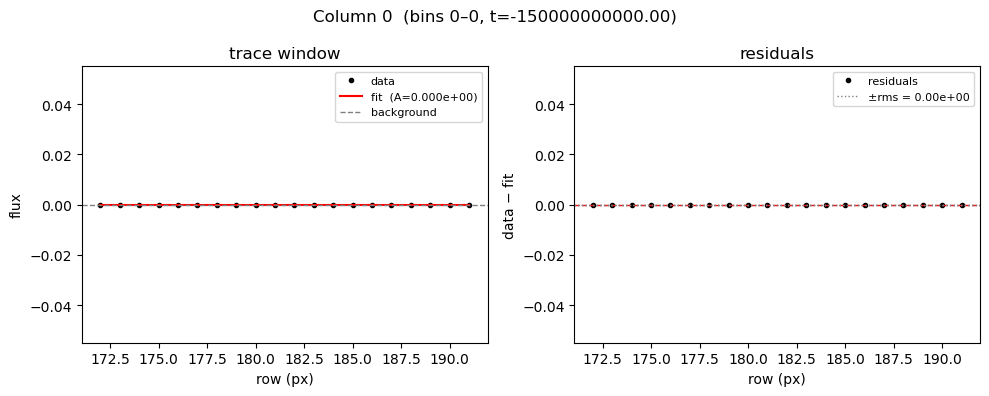

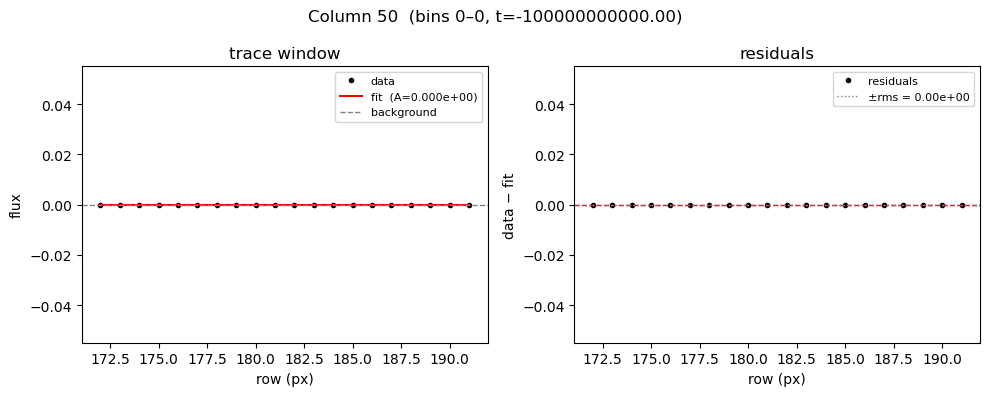

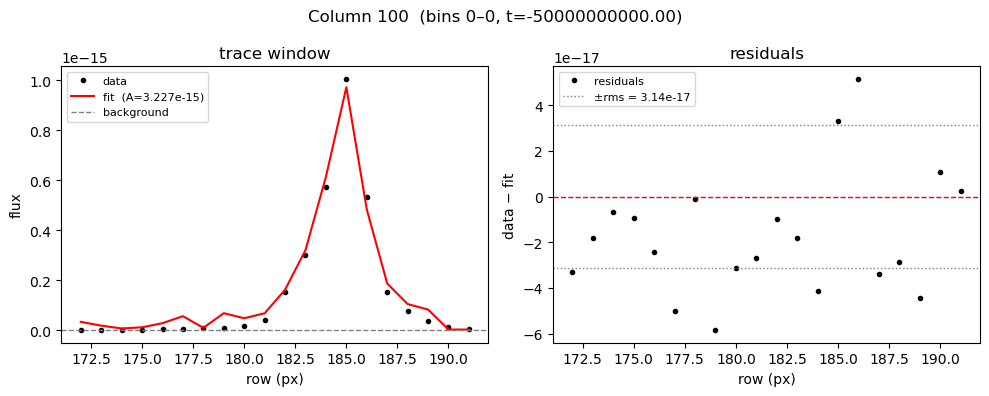

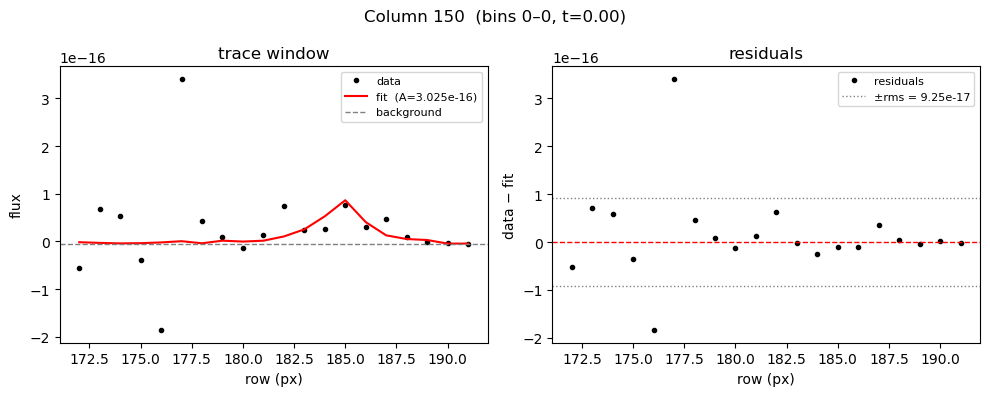

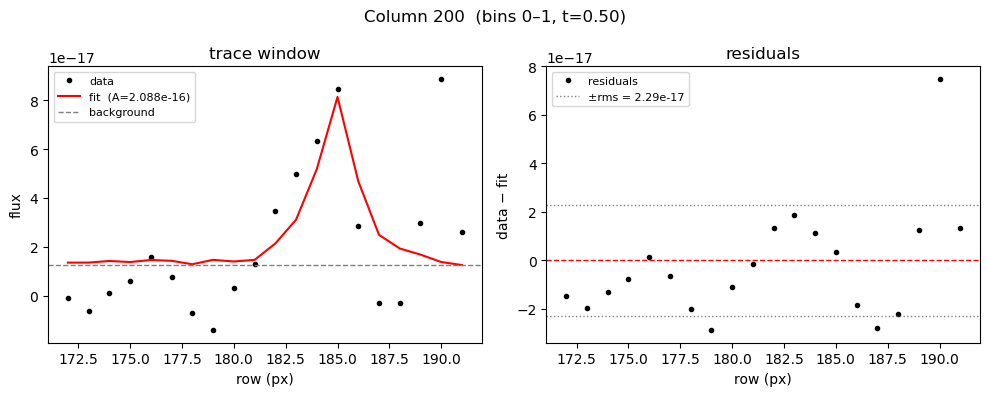

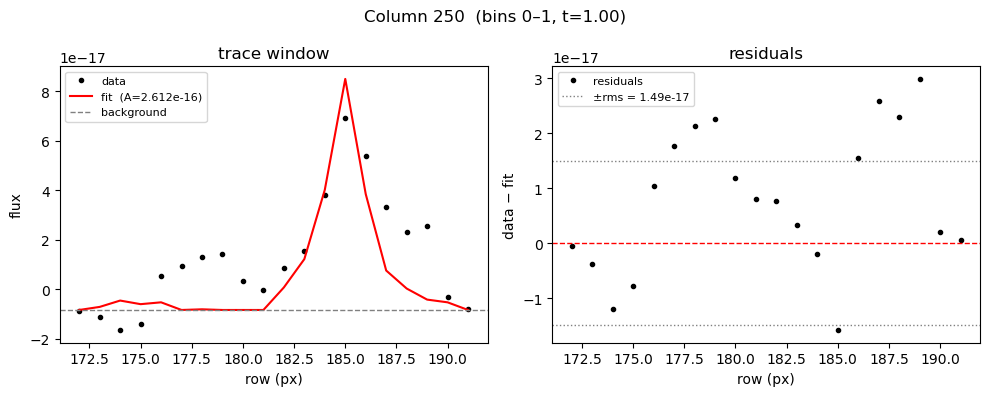

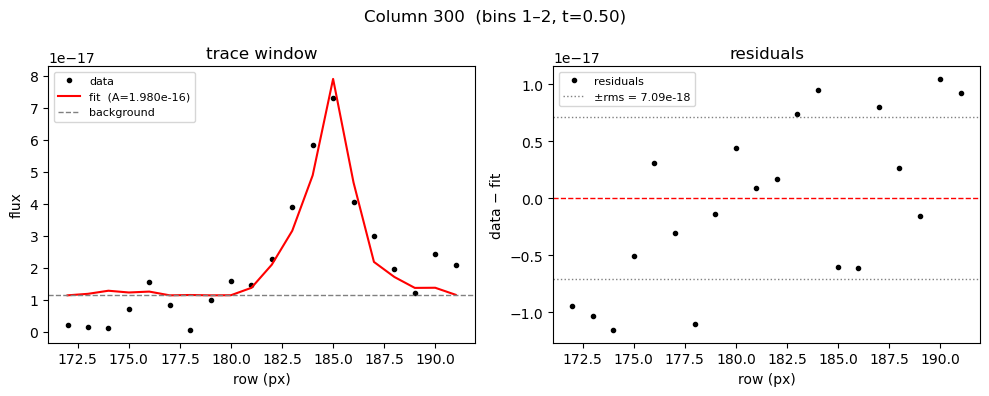

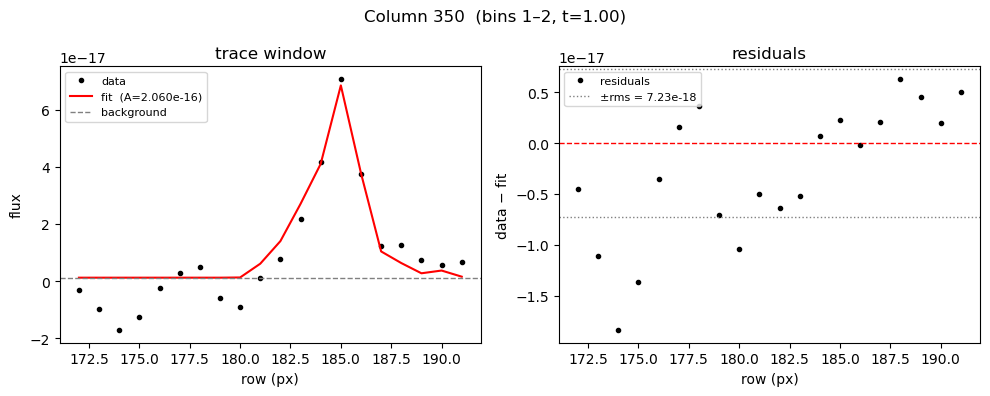

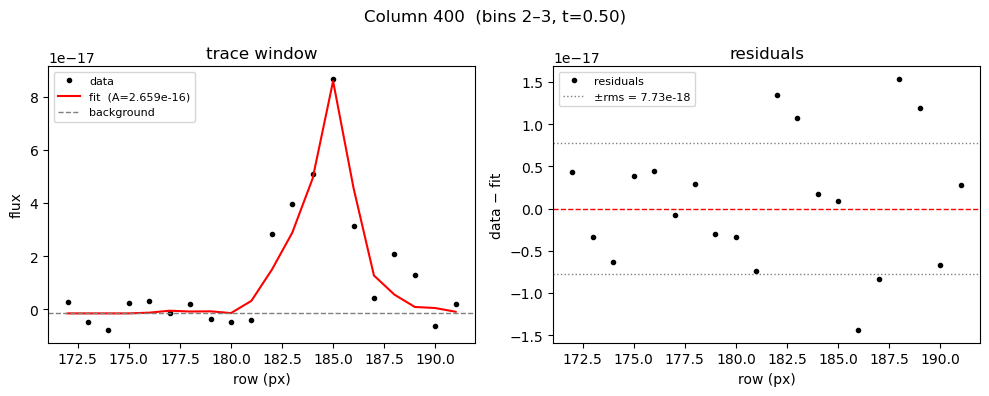

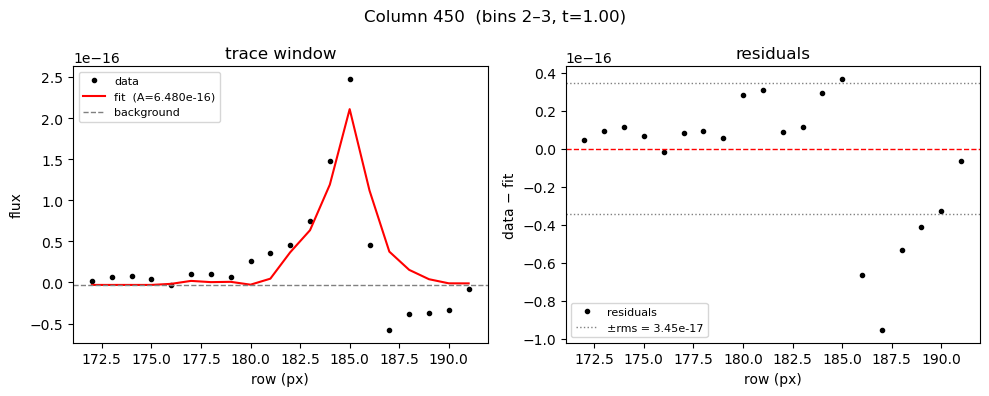

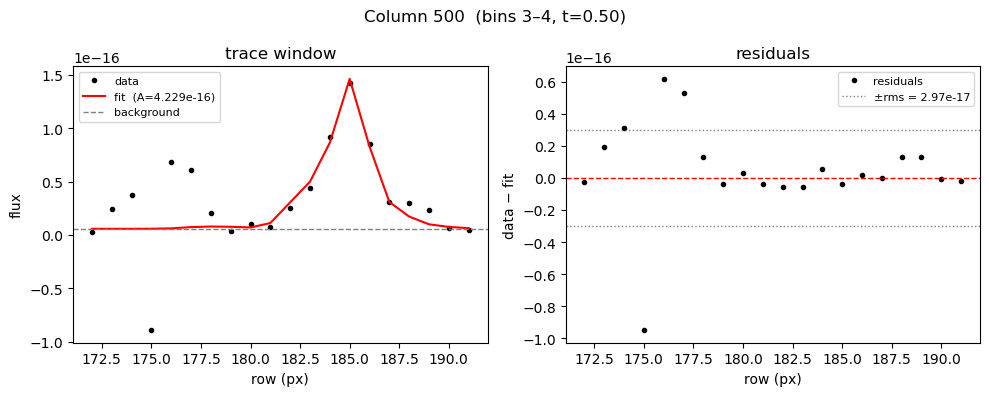

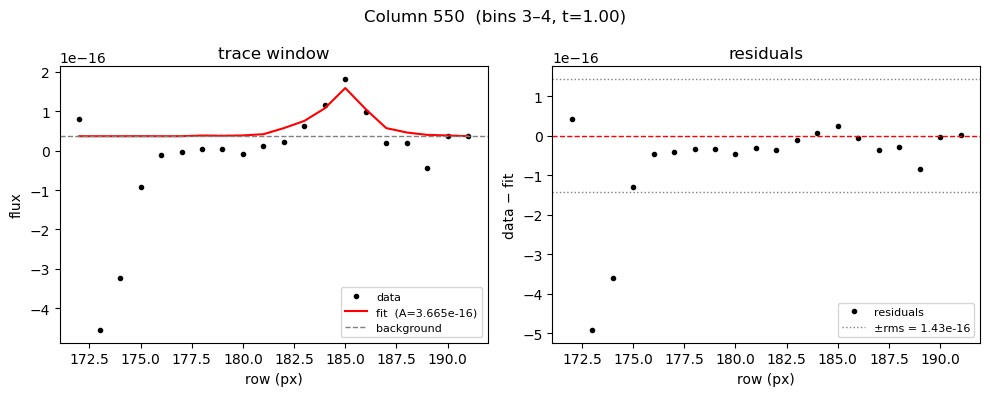

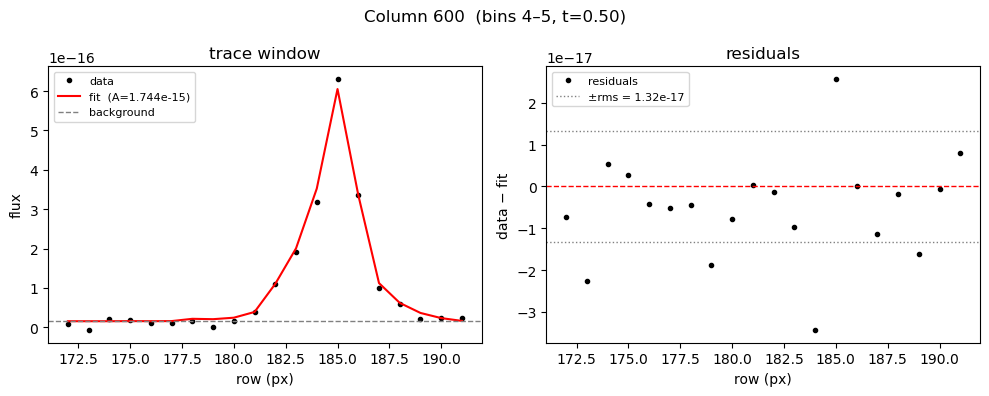

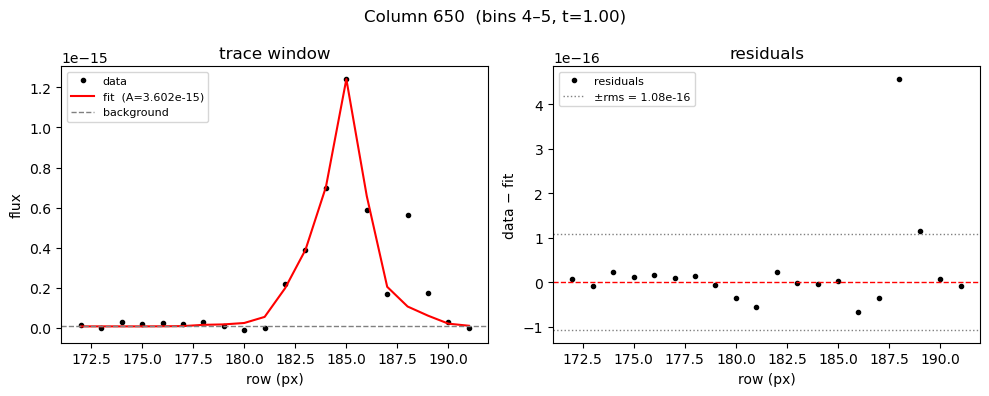

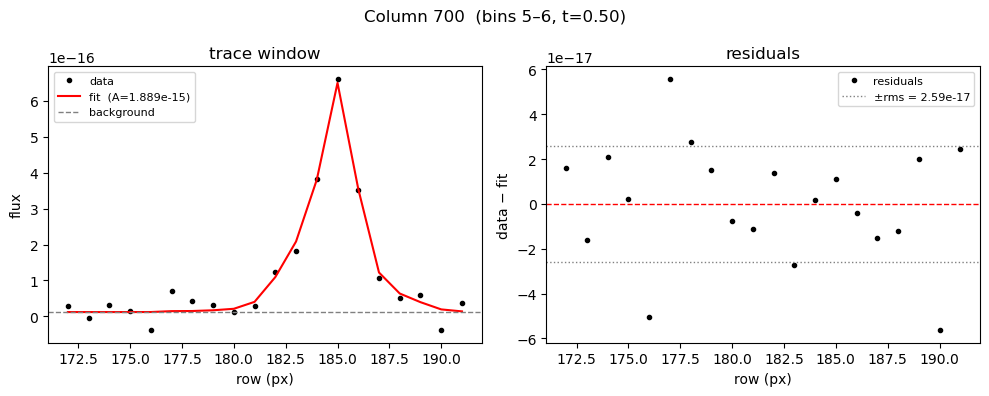

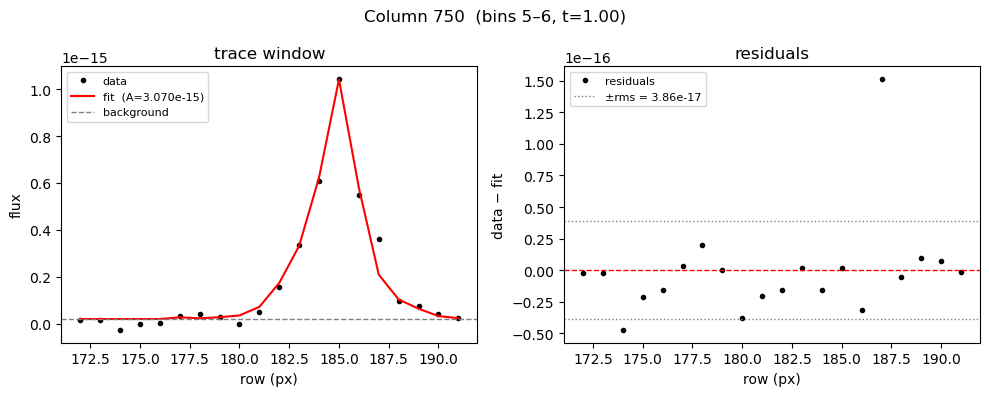

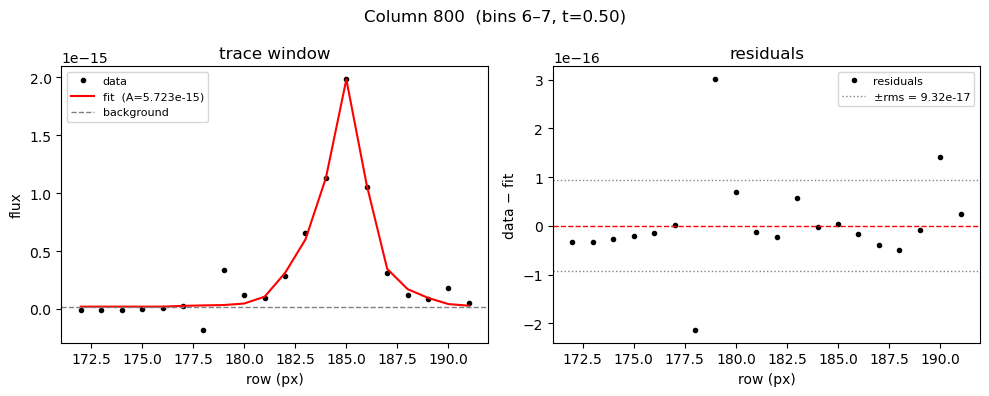

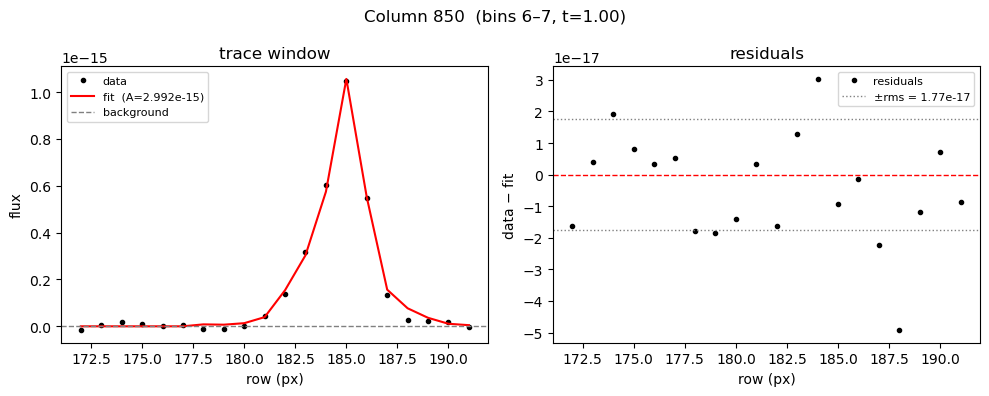

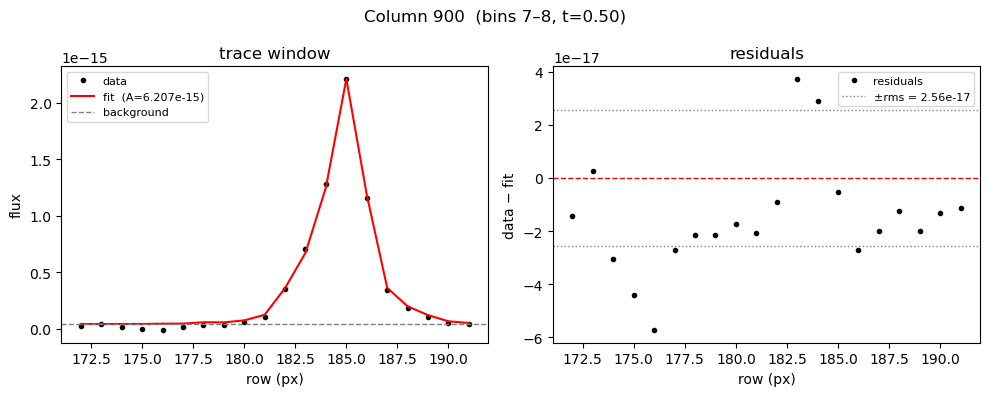

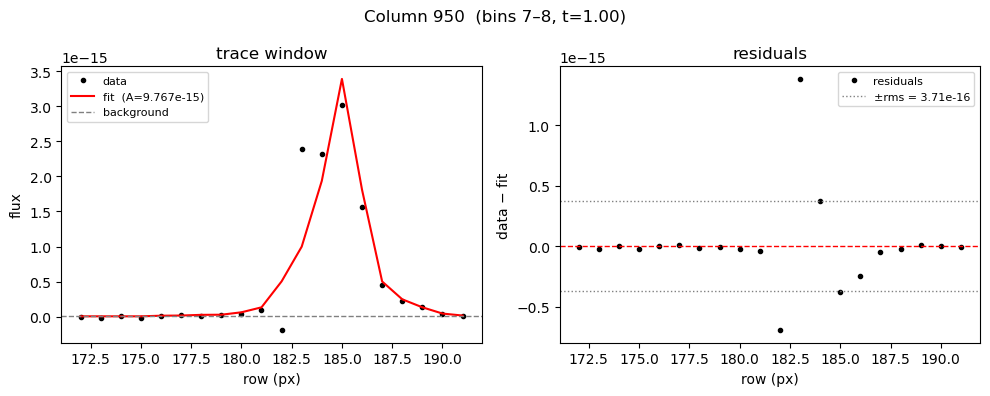

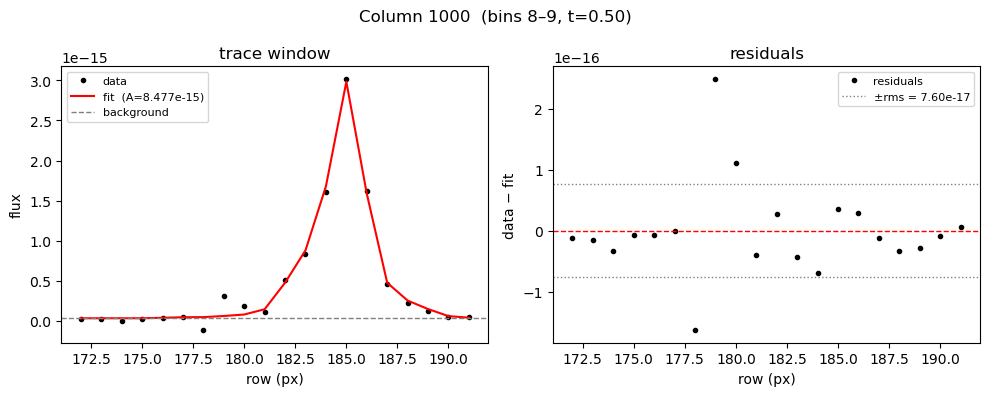

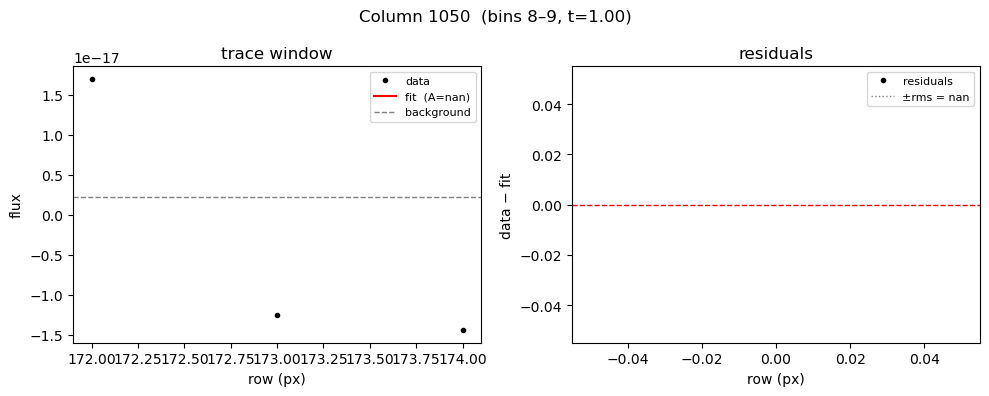

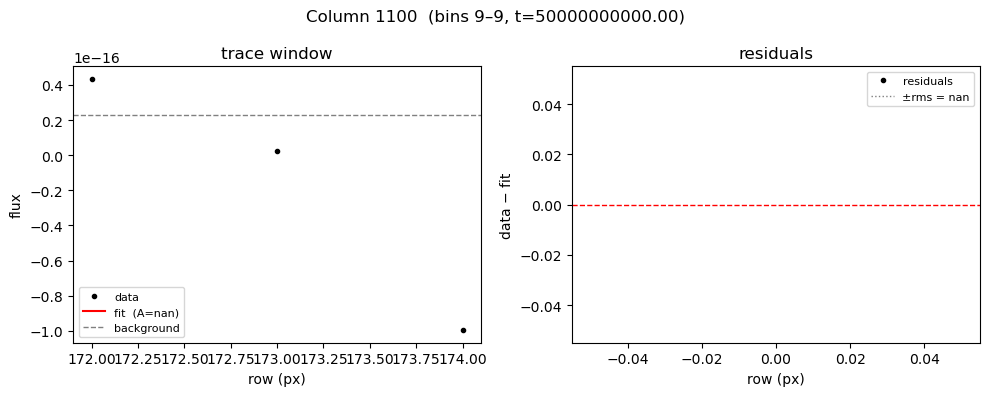

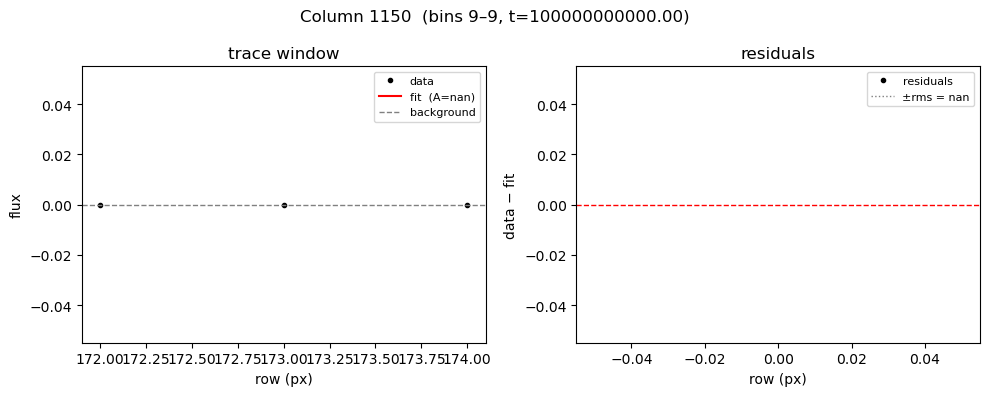

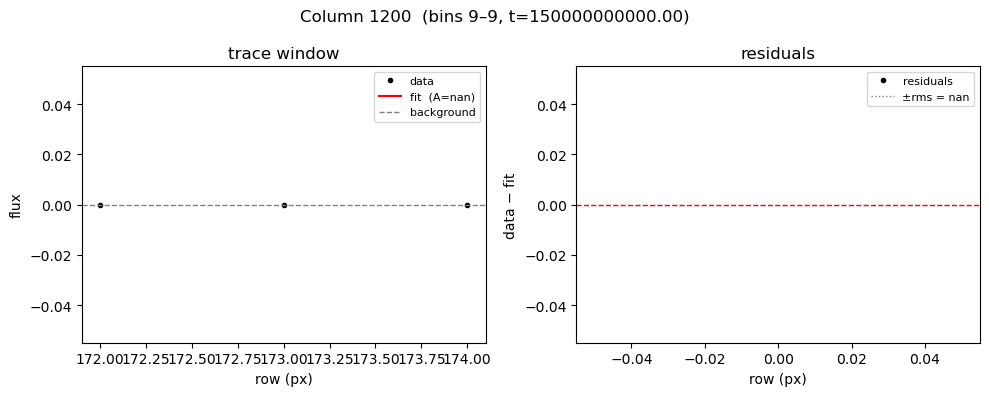

Done. 1011/1201 columns extracted successfully.


In [26]:
spectrum_400, spectrum_err_400, fit_params = extract_spectrum(
    data        = sci,
    yrange      = yrange,
    trace_center = trace_center - 400, # should be the farthest one away
    half_window  = 10,
    bin_size     = 100,
    plot         = True,
    plot_every   = 50
)

Stage 1: building master profiles...
  bin  0 (cols    0– 150): REJECTED — borrowing from nearest valid bin
  bin  1 (cols  150– 300): peak row 574
  bin  2 (cols  300– 450): peak row 573
  bin  3 (cols  450– 600): peak row 576
    rejected: multi-peaked profile (2 peaks above half-max)
  bin  4 (cols  600– 750): REJECTED — borrowing from nearest valid bin
  bin  5 (cols  750– 900): peak row 570
    rejected: multi-peaked profile (2 peaks above half-max)
  bin  6 (cols  900–1050): REJECTED — borrowing from nearest valid bin
    rejected: peak at window edge (row 565)
  bin  7 (cols 1050–1200): REJECTED — borrowing from nearest valid bin
4/8 bins built successfully.

Stage 2: extracting spectrum...


/var/folders/mv/dnh3zwd138x8994mysrnnsch0000gn/T/ipykernel_18496/1147327572.py:39: RuntimeWarning: All-NaN slice encountered
  bin_col = np.nanmedian(cols, axis=1)
/var/folders/mv/dnh3zwd138x8994mysrnnsch0000gn/T/ipykernel_18496/1147327572.py:40: RuntimeWarning: All-NaN slice encountered
  bg      = np.nanmedian(np.concatenate([bin_col[:2], bin_col[-2:]]))


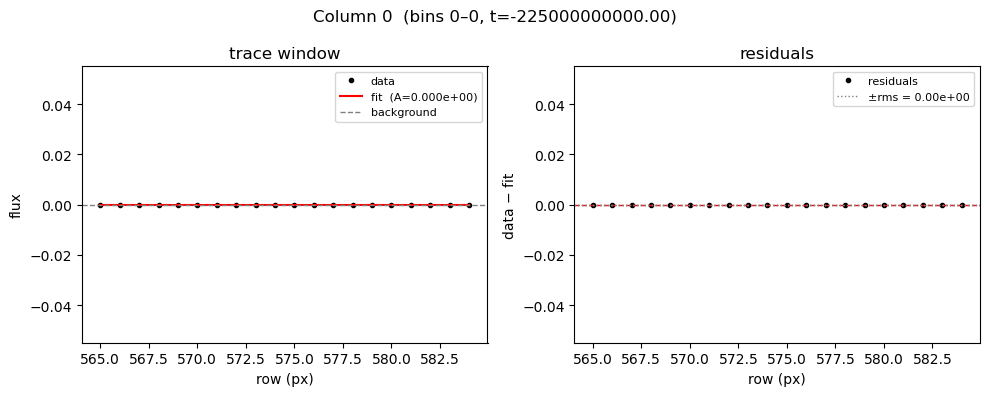

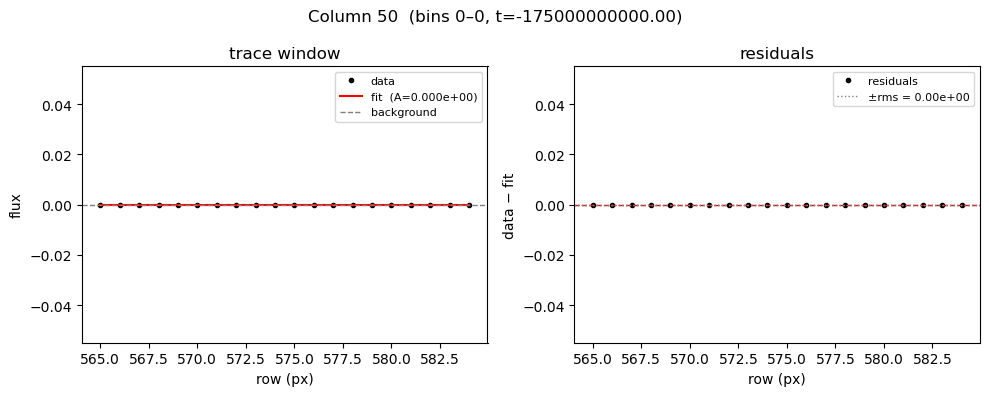

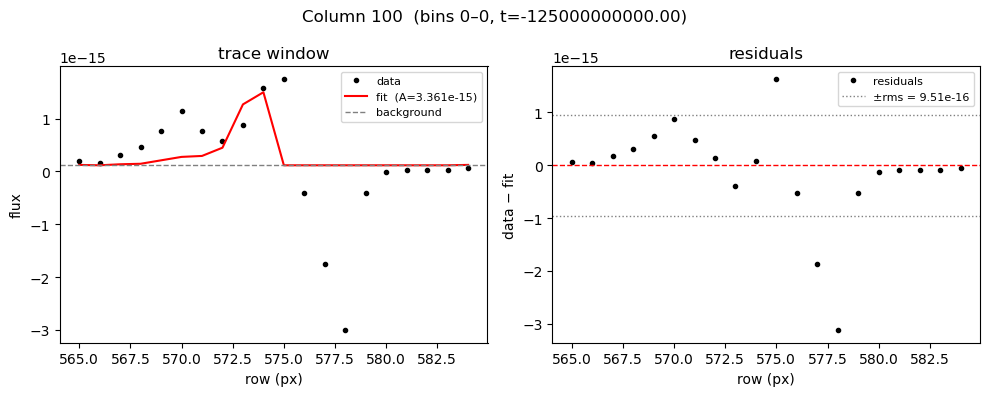

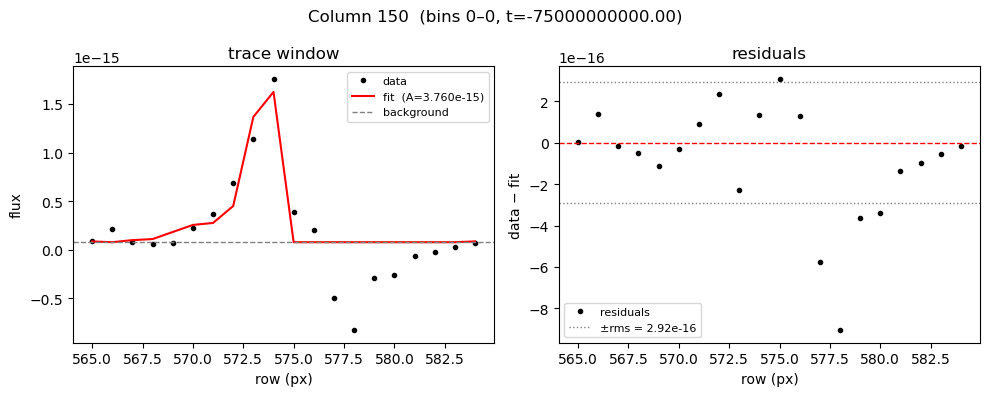

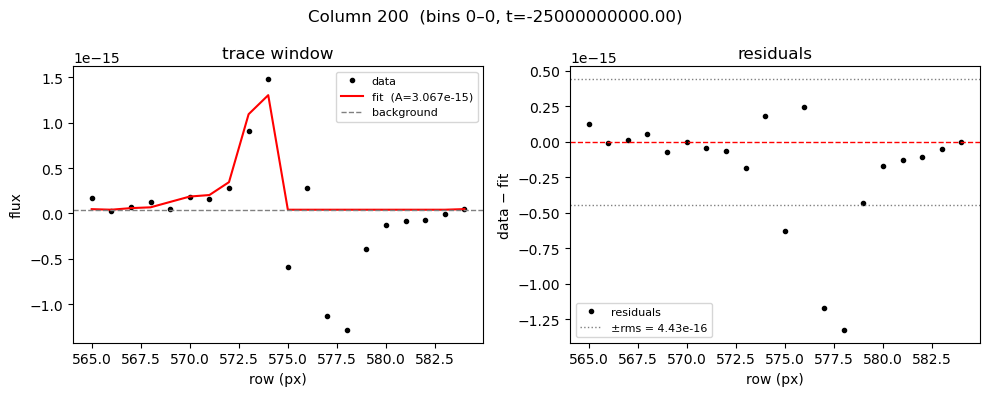

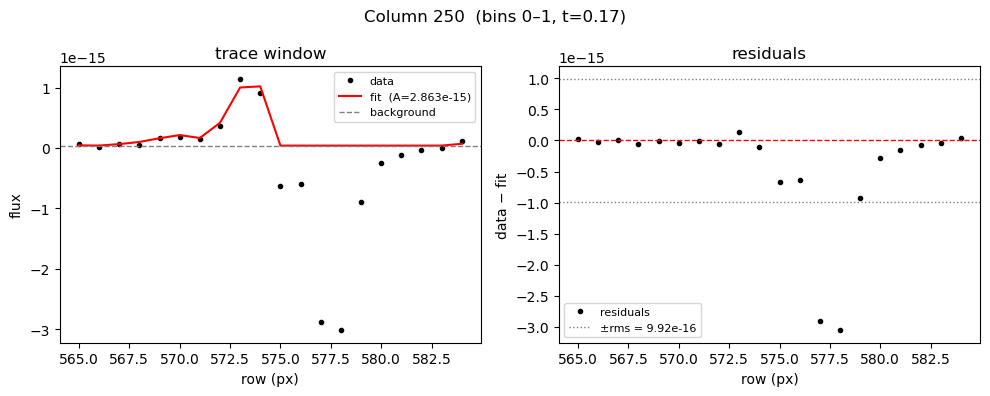

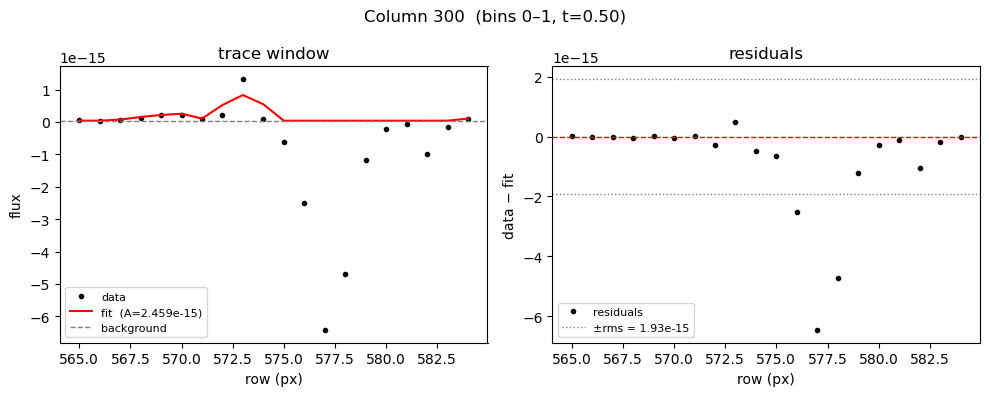

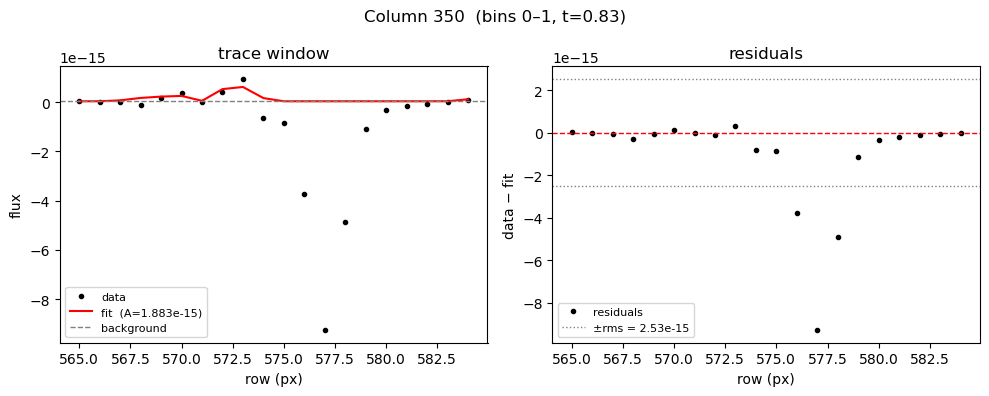

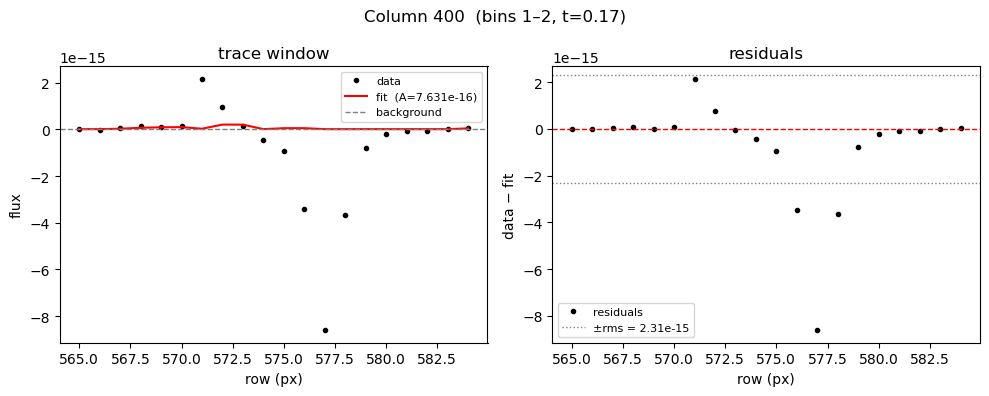

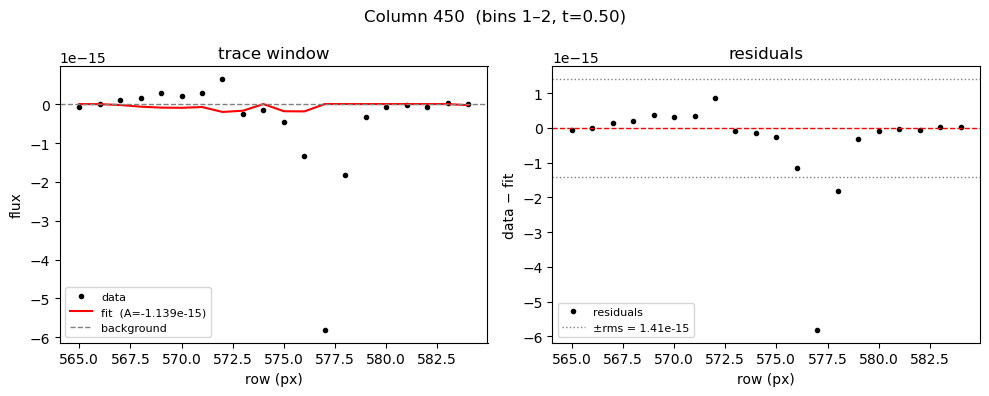

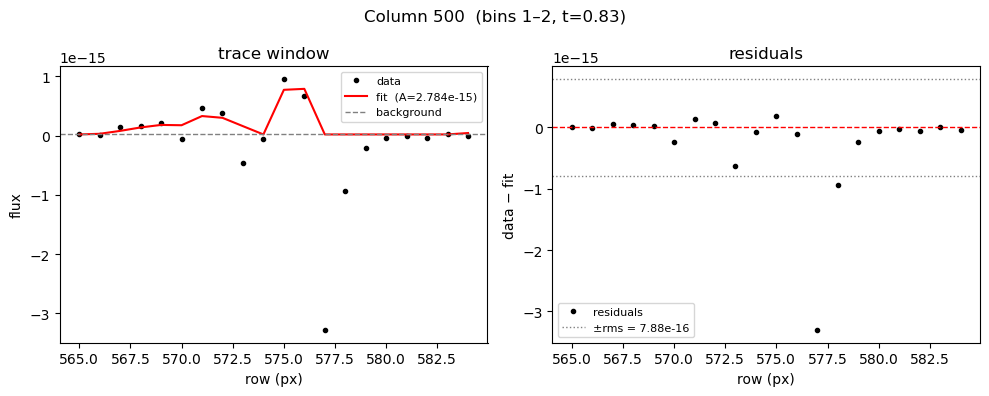

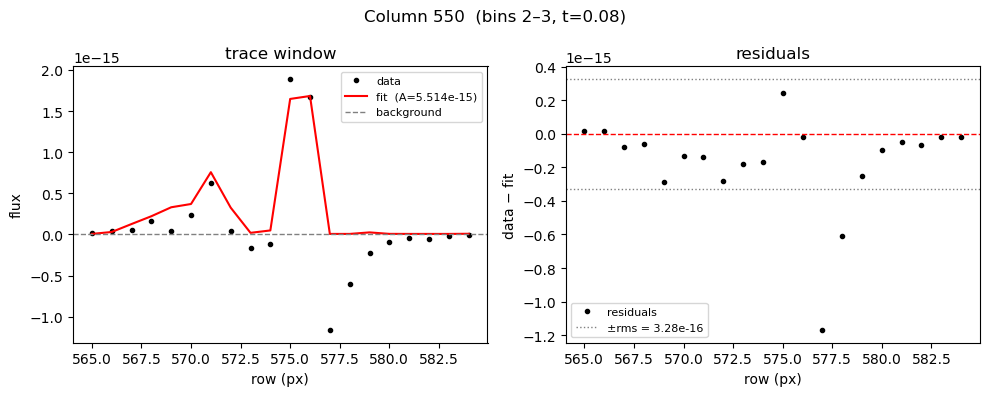

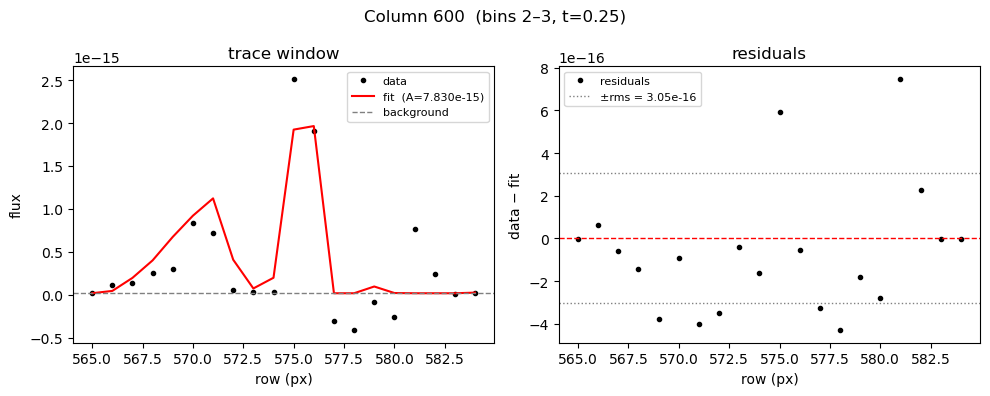

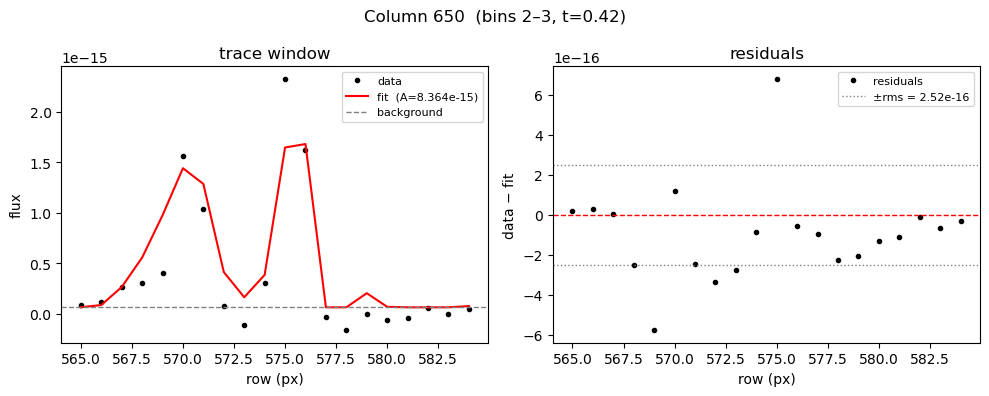

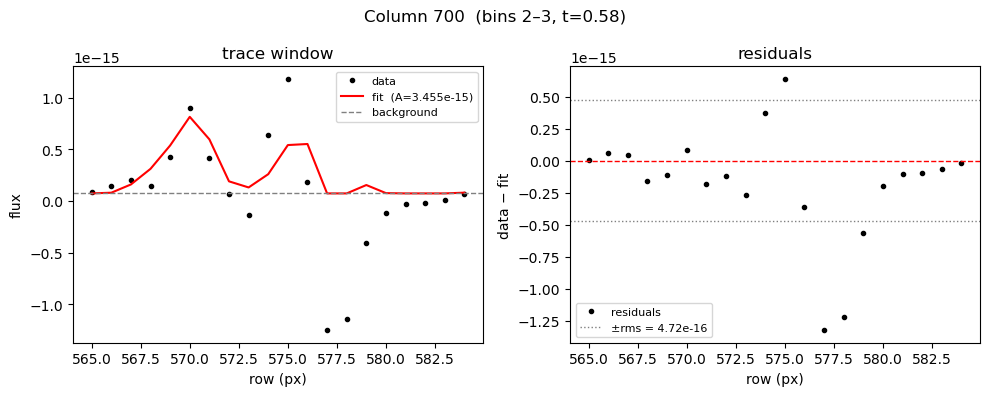

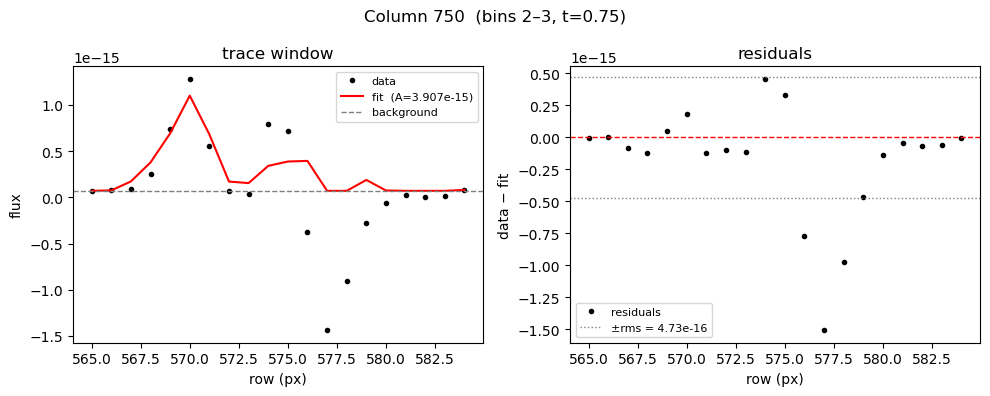

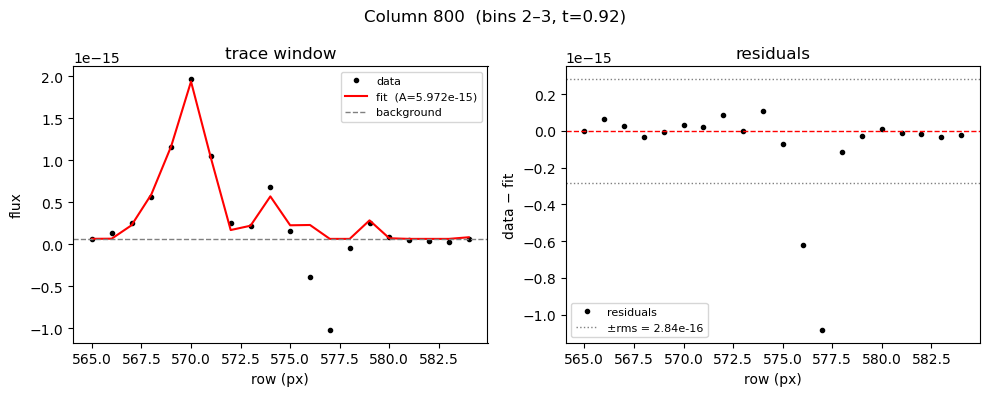

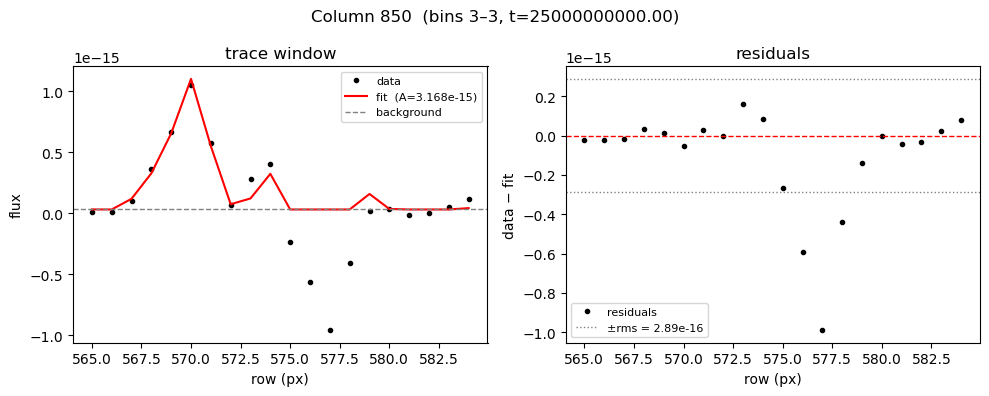

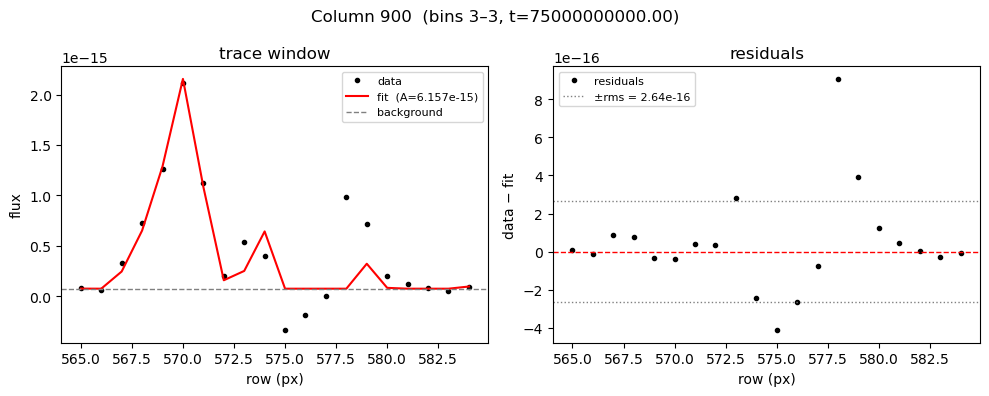

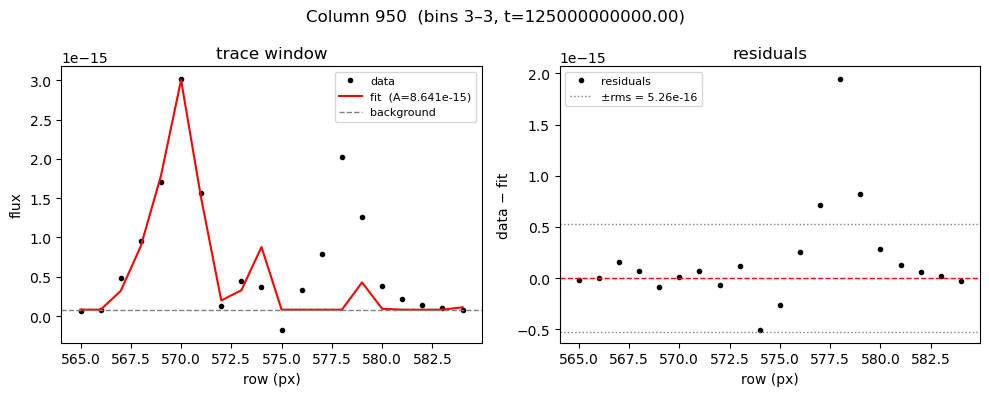

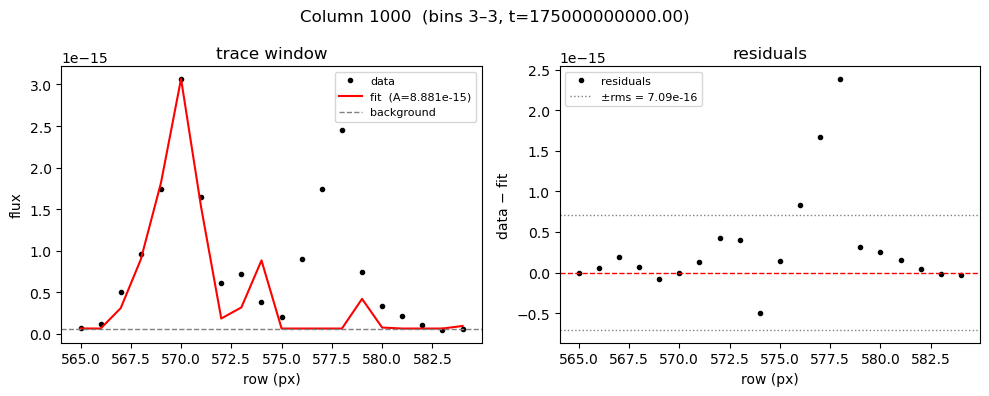

/var/folders/mv/dnh3zwd138x8994mysrnnsch0000gn/T/ipykernel_18496/1147327572.py:137: RuntimeWarning: All-NaN slice encountered
  bg      = np.nanmedian(np.concatenate([col_data[:2], col_data[-2:]]))


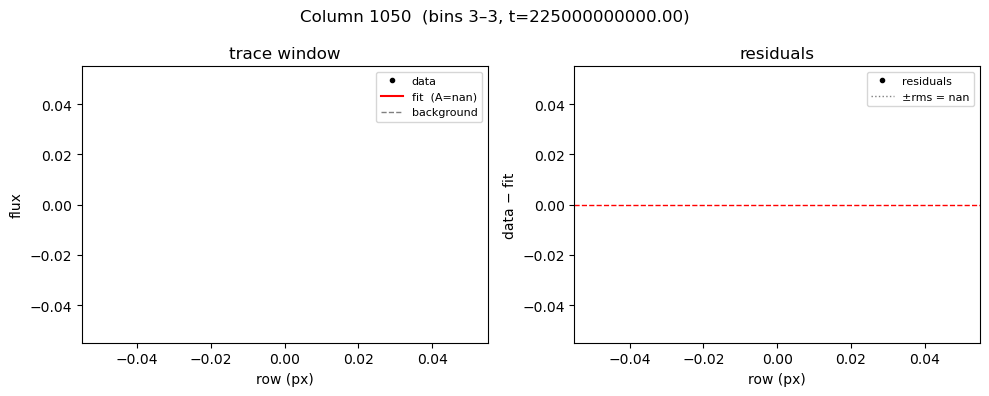

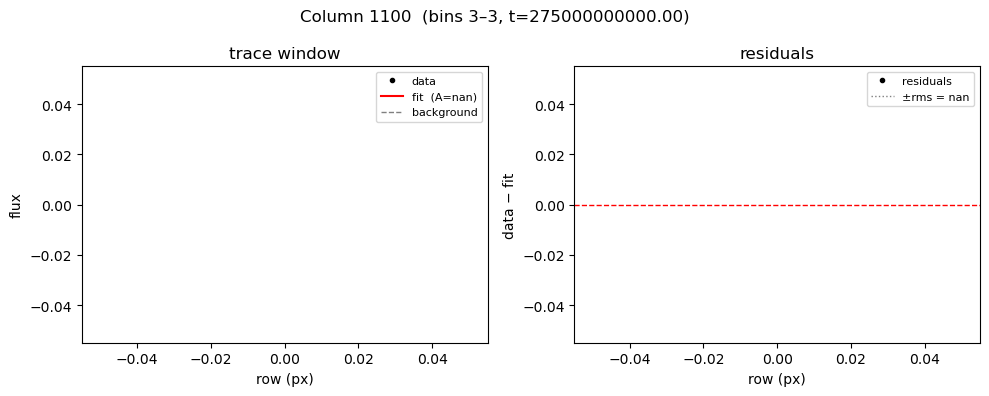

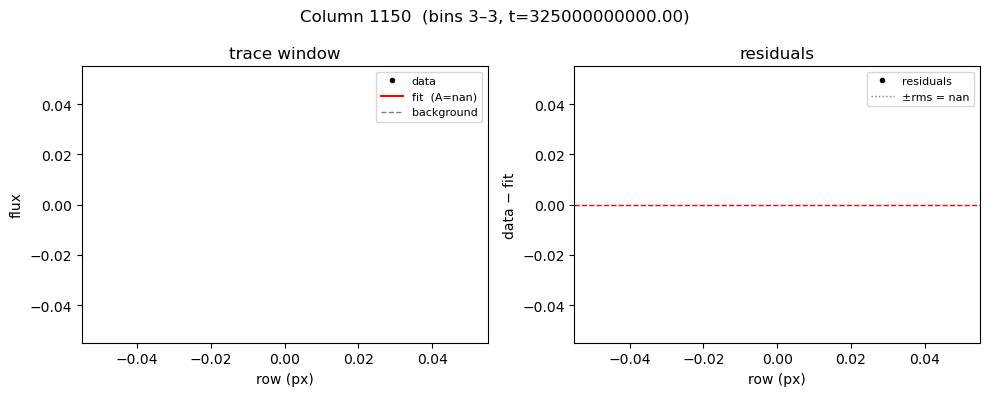

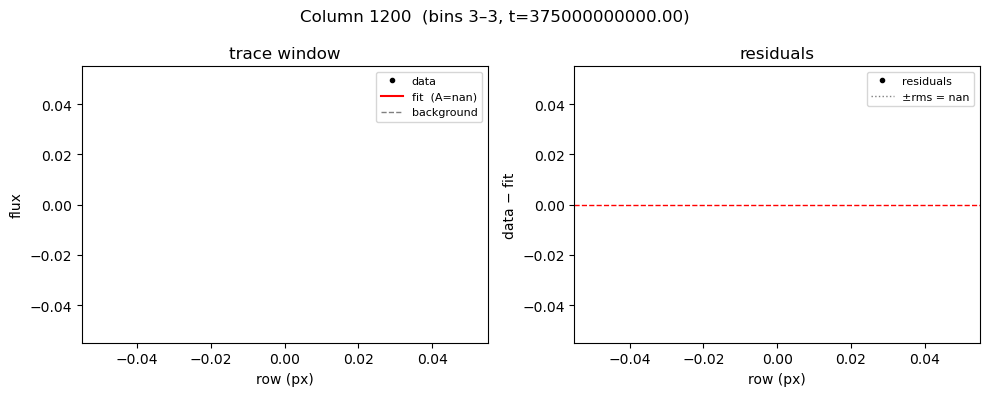

Done. 1011/1201 columns extracted successfully.


In [29]:
spectrum_7, spectrum_err_7, fit_params = extract_spectrum(
    data        = sci,
    yrange      = yrange,
    trace_center = trace_center - 7, # should be the closest one
    half_window  = 10,
    bin_size     = 150,
    plot         = True,
    plot_every   = 50
)

In [27]:
# loop over all the separations 
offsets = [7, 15, 35, 65, 100, 170, 270, 400]  

extractions = {}

for offset in offsets:
    print(f"\n{'='*50}")
    print(f"Extracting trace at offset {offset} (row {trace_center - offset})")
    print(f"{'='*50}")
    
    spectrum, spectrum_err, fit_params = extract_spectrum(
        data         = sci,
        yrange       = yrange,
        trace_center = trace_center - offset,
        half_window  = 10,
        bin_size     = 150,
        plot         = False,
        plot_every   = 50
    )
    
    extractions[offset] = {
        'spectrum':     spectrum,
        'spectrum_err': spectrum_err,
        'fit_params':   fit_params,
        'trace_row':    trace_center - offset
    }


Extracting trace at offset 7 (row 575)
Stage 1: building master profiles...
  bin  0 (cols    0– 150): REJECTED — borrowing from nearest valid bin
  bin  1 (cols  150– 300): peak row 574
  bin  2 (cols  300– 450): peak row 573
  bin  3 (cols  450– 600): peak row 576
    rejected: multi-peaked profile (2 peaks above half-max)
  bin  4 (cols  600– 750): REJECTED — borrowing from nearest valid bin
  bin  5 (cols  750– 900): peak row 570
    rejected: multi-peaked profile (2 peaks above half-max)
  bin  6 (cols  900–1050): REJECTED — borrowing from nearest valid bin
    rejected: peak at window edge (row 565)
  bin  7 (cols 1050–1200): REJECTED — borrowing from nearest valid bin
4/8 bins built successfully.

Stage 2: extracting spectrum...
Done. 1011/1201 columns extracted successfully.

Extracting trace at offset 15 (row 567)
Stage 1: building master profiles...
  bin  0 (cols    0– 150): REJECTED — borrowing from nearest valid bin
  bin  1 (cols  150– 300): peak row 574
    rejected: mu

/var/folders/mv/dnh3zwd138x8994mysrnnsch0000gn/T/ipykernel_18496/1147327572.py:39: RuntimeWarning: All-NaN slice encountered
  bin_col = np.nanmedian(cols, axis=1)
/var/folders/mv/dnh3zwd138x8994mysrnnsch0000gn/T/ipykernel_18496/1147327572.py:40: RuntimeWarning: All-NaN slice encountered
  bg      = np.nanmedian(np.concatenate([bin_col[:2], bin_col[-2:]]))
/var/folders/mv/dnh3zwd138x8994mysrnnsch0000gn/T/ipykernel_18496/1147327572.py:137: RuntimeWarning: All-NaN slice encountered
  bg      = np.nanmedian(np.concatenate([col_data[:2], col_data[-2:]]))


  bin  0 (cols    0– 150): REJECTED — borrowing from nearest valid bin
  bin  1 (cols  150– 300): peak row 415
  bin  2 (cols  300– 450): peak row 415
  bin  3 (cols  450– 600): peak row 415
  bin  4 (cols  600– 750): peak row 415
  bin  5 (cols  750– 900): peak row 415
  bin  6 (cols  900–1050): peak row 415
    rejected: peak at window edge (row 402)
  bin  7 (cols 1050–1200): REJECTED — borrowing from nearest valid bin
6/8 bins built successfully.

Stage 2: extracting spectrum...
Done. 1011/1201 columns extracted successfully.

Extracting trace at offset 270 (row 312)
Stage 1: building master profiles...
  bin  0 (cols    0– 150): REJECTED — borrowing from nearest valid bin
  bin  1 (cols  150– 300): peak row 315
  bin  2 (cols  300– 450): peak row 315
  bin  3 (cols  450– 600): peak row 315
  bin  4 (cols  600– 750): peak row 315
  bin  5 (cols  750– 900): peak row 315
  bin  6 (cols  900–1050): peak row 315
    rejected: peak at window edge (row 302)
  bin  7 (cols 1050–1200): REJ

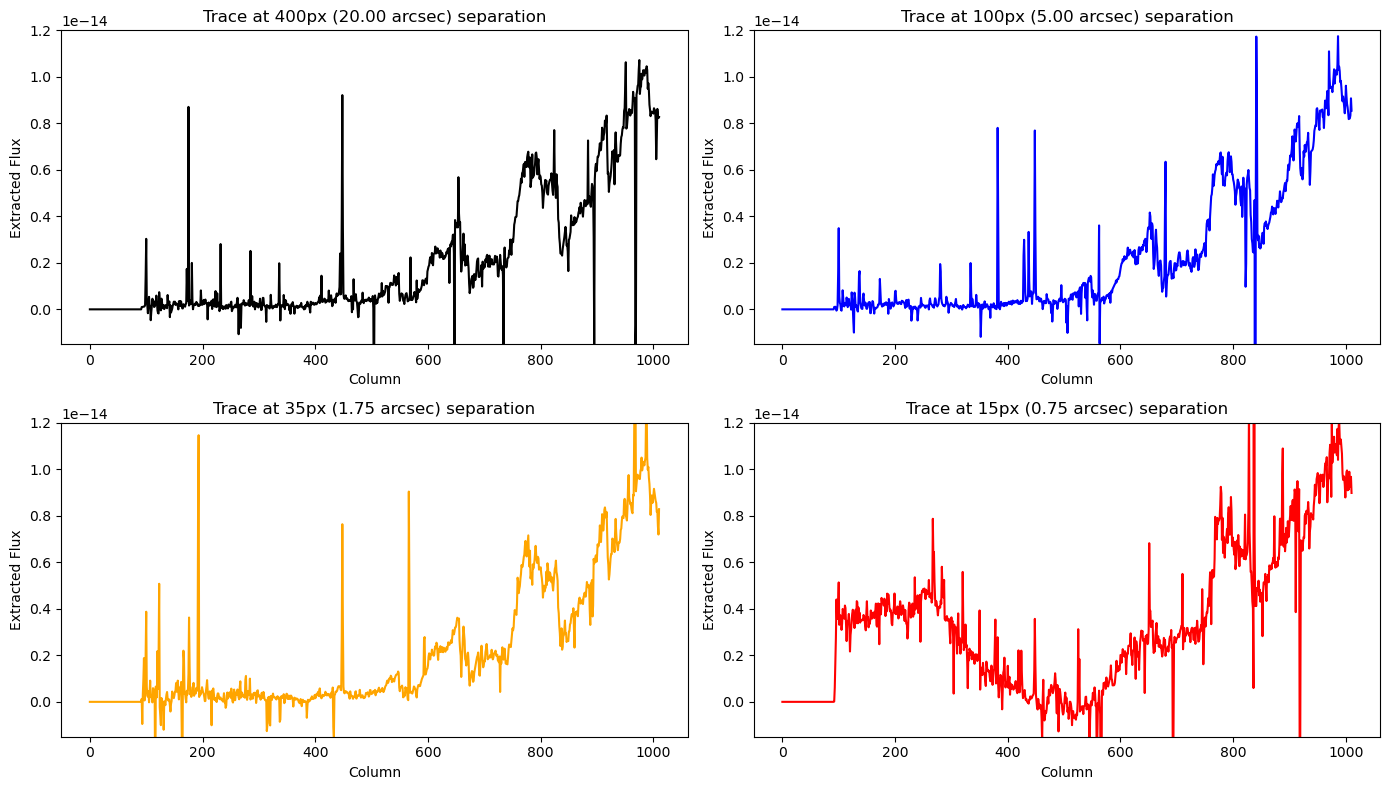

In [28]:
# plot them and take a look!
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

panels = [
    (400, axes[0, 0],'black'),
    (100, axes[0, 1],'blue'),
    ( 35, axes[1, 0],'orange'),
    ( 15, axes[1, 1],'red'),
]



for offset, ax, color in panels:
    ax.plot(extractions[offset]['spectrum'], c=color)
    ax.set_xlabel('Column')
    ax.set_ylabel('Extracted Flux')
    ax.set_title(f'Trace at {offset}px ({offset * 0.05:.2f} arcsec) separation')
    ax.set_ylim(-0.15e-14, 1.2e-14)

plt.tight_layout()
plt.show()